# Census Data Demo: A Comprehensive Guide

This notebook provides a comprehensive introduction to using the `censusdis` library to fetch, analyze, and visualize US Census data. We will explore various datasets, geographies, and advanced features, with a focus on applications for "Energy Justice" analysis.

**Reference**: [censusdis Introduction](https://censusdis.readthedocs.io/en/latest/intro.html)

## Table of Contents
1.  [Setup and Imports](#setup)
2.  [Part 1: Discovering Data](#part1)
3.  [Part 2: Case Study - Puerto Rico Demographics (ACS5)](#part2)
4.  [Part 3: Case Study - Population Trends (ACS1)](#part3)
5.  [Part 4: Advanced Geography & Filters](#part4)
6.  [Part 5: Visualization & Analysis](#part5)
7.  [Part 6: Spatial Operations (PV Data Integration - California)](#part6)

<a id="setup"></a>
## 1. Setup and Imports

We start by importing `censusdis` and other necessary libraries.

In [1]:
import censusdis.data as ced
import censusdis.states as states
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely import wkt
from shapely.geometry import Point, box

# Ensure plots display inline
%matplotlib inline

<a id="part1"></a>
## 2. Part 1: Discovering Data

The US Census Bureau provides a vast amount of data across many datasets (e.g., ACS, Decennial, PEP). Understanding how to find the right dataset and variables is the first step.

### Key Resources
-   **[Querying Available Data Sets](https://github.com/censusdis/censusdis/blob/main/notebooks/Querying%20Available%20Data%20Sets.ipynb)**: Learn how to list available datasets programmatically.
-   **[Lesson 1: Basic Queries](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%201%20Basic%20Queries.ipynb)**: A tutorial on the basics of querying.
-   **[Lesson 3: Variables](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%203%20Variables.ipynb)**: Deep dive into finding and understanding variables.
-   **[censusdis Data Module](https://censusdis.readthedocs.io/en/latest/data.html#module-censusdis.data)**: Official API documentation.

### Common Datasets
-   **ACS5 (American Community Survey 5-Year Estimates)**: Detailed demographics (income, education, housing) down to the Block Group level. Great for small areas.
-   **PEP (Population Estimates Program)**: Annual estimates of population and components of change. Good for tracking trends at State/County levels.
-   **DEC (Decennial Census)**: The official count every 10 years.

<a id="part2"></a>
## 3. Part 2: Case Study - Puerto Rico Demographics (ACS5)

In this section, we focus on fetching demographic data for **Puerto Rico** to support Energy Justice analysis. We will use the **ACS 5-Year Estimates**.

**References**:
-   [Data With Geometry](https://censusdis.readthedocs.io/en/latest/nb/Data%20With%20Geometry.html)
-   [Lesson 2: Maps](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%202%20Maps.ipynb)
-   [Seeing White](https://github.com/censusdis/censusdis/blob/main/notebooks/Seeing%20White.ipynb): An example of analyzing racial demographics.

In [2]:
# Define Variables
# B19013_001E: Median Household Income
# B01003_001E: Total Population
variables = ['B19013_001E', 'B01003_001E']

# Fetch Data for Puerto Rico (State 72) at Census Tract level
print("Fetching ACS5 data for Puerto Rico...")
pr_gdf = ced.download(
    dataset='acs/acs5',
    vintage=2022,
    download_variables=variables,
    state='72',          # FIPS code for Puerto Rico
    tract='*',           # All tracts
    with_geometry=True   # Include geometry for mapping
)

# Rename columns for clarity
pr_gdf = pr_gdf.rename(columns={
    'B19013_001E': 'Median_Income',
    'B01003_001E': 'Total_Population'
})

pr_gdf.head()

Fetching ACS5 data for Puerto Rico...


,STATE,COUNTY,TRACT,Median_Income,Total_Population,geometry
0,72,001,956300,16406.0,3690,"POLYGON ((-66.79442 18.24988, -66.78899 18.249..."
1,72,001,956400,21895.0,2456,"POLYGON ((-66.83724 18.19271, -66.83358 18.194..."
2,72,001,956500,16582.0,2402,"POLYGON ((-66.81692 18.15796, -66.81437 18.162..."
3,72,001,956600,14773.0,2634,"POLYGON ((-66.73079 18.16964, -66.73073 18.169..."
4,72,001,956700,18750.0,1877,"POLYGON ((-66.72612 18.16219, -66.72312 18.163..."


<a id="part3"></a>
## 4. Part 3: Case Study - Population Trends (ACS1)

To look at broader trends or more recent data for larger geographies, we can use the **ACS 1-Year Estimates** (ACS1). This is often more readily available than PEP for specific demographic variables.

**Reference**: [Population Change 2020-2021](https://censusdis.readthedocs.io/en/latest/nb/Population%20Change%202020-2021.html#Part-2:-Using-the-Population-Estimates-Dataset)

Let's look at the total population for all US States using ACS1.

In [3]:
# Fetch Population for all US States using ACS1 (1-Year Estimates)
# B01003_001E: Total Population
print("Fetching ACS1 data for US States...")
acs1_gdf = ced.download(
    dataset='acs/acs1',
    vintage=2022,
    download_variables=['B01003_001E'],
    state='*',           # All states
    with_geometry=True
)

acs1_gdf = acs1_gdf.rename(columns={'B01003_001E': 'Total_Population'})
acs1_gdf.head()

Fetching ACS1 data for US States...


,STATE,Total_Population,geometry
0,01,5074296,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
1,02,733583,"MULTIPOLYGON (((-152.85278 70.89539, -152.8498..."
2,04,7359197,"POLYGON ((-114.81629 32.50804, -114.81432 32.5..."
3,05,3045637,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
4,06,39029342,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."


<a id="part4"></a>
## 5. Part 4: Advanced Geography & Filters

Census data is hierarchical. You can query data at various levels (State -> County -> Tract -> Block Group) and apply filters to select specific regions.

**References**:
-   [Lesson 4: Query Filters](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%204%20Query%20Filters.ipynb)
-   [Lesson 5: Advanced Geography](https://github.com/censusdis/censusdis-tutorial-2024/blob/main/Lessons/Lesson%205%20Advanced%20Geography.ipynb)

### Example: Specific Counties in New Jersey
Let's fetch data for specific counties in New Jersey (State 34).

In [4]:
# Fetch data for specific counties in New Jersey
# 003: Bergen County, 013: Essex County, 017: Hudson County
nj_counties = ['003', '013', '017']

print("Fetching data for specific NJ counties...")
nj_gdf = ced.download(
    dataset='acs/acs5',
    vintage=2022,
    download_variables=['B01003_001E'], # Total Population
    state='34',          # New Jersey
    county=nj_counties,  # Filter by county list
    with_geometry=True
)

nj_gdf

Fetching data for specific NJ counties...


,STATE,COUNTY,B01003_001E,geometry
0,34,003,953243,"POLYGON ((-74.27066 41.02103, -74.25046 41.060..."
1,34,013,853374,"POLYGON ((-74.37727 40.76118, -74.37576 40.762..."
2,34,017,712029,"MULTIPOLYGON (((-74.0422 40.69997, -74.039 40...."


<a id="part5"></a>
## 6. Part 5: Visualization & Analysis

Visualizing the data is crucial for identifying spatial patterns. We will plot the Median Household Income for Puerto Rico.

**Reference**: [censusdis Maps Module](https://censusdis.readthedocs.io/en/latest/maps.html)

### Energy Justice Context
By mapping income levels, we can identify disadvantaged communities. Spatially joining this with our Solar Panel dataset allows us to assess whether solar adoption is equitable across different income brackets.

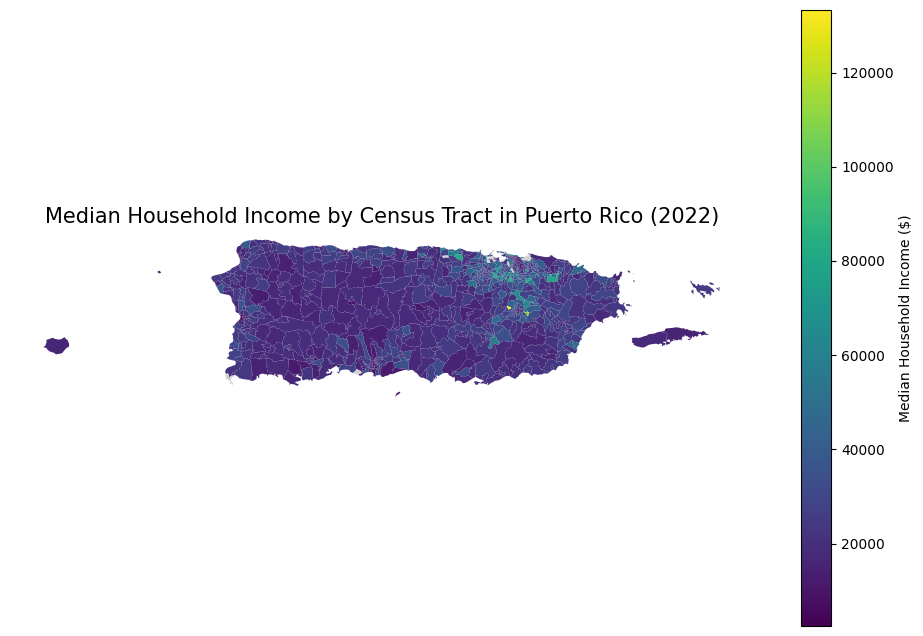

In [5]:
# Plot Median Household Income for Puerto Rico
fig, ax = plt.subplots(figsize=(12, 8))

pr_gdf.plot(
    column='Median_Income',
    legend=True,
    legend_kwds={'label': "Median Household Income ($)"},
    cmap='viridis',
    missing_kwds={'color': 'lightgrey', 'label': 'Missing Data'},
    ax=ax
)

ax.set_title("Median Household Income by Census Tract in Puerto Rico (2022)", fontsize=15)
ax.axis('off')
plt.show()

<a id="part6"></a>
## 7. Part 6: Spatial Operations (PV Data Integration - California)

A key part of our analysis involves relating our Solar Panel (PV) dataset to these Census demographics. 

**Update**: To ensure we have a dense enough dataset for meaningful analysis, we will focus this section on **California** (State '06'), which has a high concentration of solar installations in our dataset.

### 6.1 Fetch and Filter PV Data
We'll use a helper function to read the GeoParquet file and filter it to the USA + Hawaii + Puerto Rico region.

In [6]:
def read_parquet_with_pandas(
    path: str,
    use_pyarrow: bool = True
) -> gpd.GeoDataFrame:
    """
    Read a Parquet file into a GeoDataFrame.
    """
    print(f"Reading data from {path}...")
    engine = 'pyarrow' if use_pyarrow else 'fastparquet'
    df = pd.read_parquet(path, engine=engine)
    
    # convert to geodataframe and convert WKT to shapely
    if 'geometry' in df.columns and df['geometry'].dtype == 'object':
        df['geometry'] = df['geometry'].apply(wkt.loads)
        
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    return gdf

# Define Dataset URI and AOI
DATASET_URI = 'https://eo-pv-elt.work/geoparquet/ccom6994_pv_dataset.parquet'

# AOI: USA + HI + PR (xmin, ymin, xmax, ymax)
AOI_BBOX = (-160.25, 17.9, -65.2, 49.4)

# Fetch and Filter
try:
    full_gdf = read_parquet_with_pandas(DATASET_URI)
    
    # Filter by Bounding Box
    print(f"Filtering to AOI: {AOI_BBOX}")
    pv_gdf = full_gdf.cx[AOI_BBOX[0]:AOI_BBOX[2], AOI_BBOX[1]:AOI_BBOX[3]]
    
    print(f"Loaded {len(pv_gdf):,} PV installations within AOI.")
    
    # Display count by dataset name
    print("\nCounts by Dataset Source:")
    print(pv_gdf.groupby('dataset_name').size())
    
except Exception as e:
    print(f"Error fetching data: {e}")
    # Fallback to empty GDF if download fails (for demo purposes)
    pv_gdf = gpd.GeoDataFrame(columns=['geometry', 'dataset_name'], crs='EPSG:4326')

Reading data from https://eo-pv-elt.work/geoparquet/ccom6994_pv_dataset.parquet...
Filtering to AOI: (-160.25, 17.9, -65.2, 49.4)
Loaded 42,874 PV installations within AOI.

Counts by Dataset Source:
dataset_name
global_harmonized_large_solar_farms_2020     4276
global_pv_inventory_sent2_spot_2021         19225
usa_cali_usgs_pv_2016                       19373
dtype: int64


### 6.2 Fetch California Census Data

We need to fetch the Census Tracts and Income data for California to match our PV data.

In [7]:
# Fetch Data for California (State 06)
print("Fetching ACS5 data for California...")
ca_gdf = ced.download(
    dataset='acs/acs5',
    vintage=2022,
    download_variables=['B19013_001E', 'B01003_001E'],
    state='06',          # FIPS code for California
    tract='*',           # All tracts
    with_geometry=True
)

ca_gdf = ca_gdf.rename(columns={
    'B19013_001E': 'Median_Income',
    'B01003_001E': 'Total_Population'
})

print(f"Fetched {len(ca_gdf):,} Census Tracts for California.")

Fetching ACS5 data for California...
Fetched 9,129 Census Tracts for California.


### 6.3 Spatial Join: Assigning California Census Tracts to PV Points

Now we perform the **Spatial Join** between our PV points and the California Census Tracts.

In [8]:
# Perform Spatial Join with California Census Tracts
print("Joining PV data with California Census Tracts...")

# Ensure CRS match
if pv_gdf.crs != ca_gdf.crs:
    pv_gdf = pv_gdf.to_crs(ca_gdf.crs)

joined_gdf = gpd.sjoin(pv_gdf, ca_gdf, how='inner', predicate='within')

print(f"Matched {len(joined_gdf):,} PV installations to California Census Tracts.")

# Robust column selection
cols_to_show = ['geometry', 'Median_Income', 'Total_Population']
if 'NAME' in joined_gdf.columns:
    cols_to_show.insert(1, 'NAME')
elif 'NAME_right' in joined_gdf.columns:
    cols_to_show.insert(1, 'NAME_right')
elif 'GEOID' in joined_gdf.columns:
    cols_to_show.insert(1, 'GEOID')

joined_gdf[cols_to_show].head()

Joining PV data with California Census Tracts...
Matched 25,185 PV installations to California Census Tracts.


,geometry,Median_Income,Total_Population
4107,"POLYGON ((-121.05719 38.63902, -121.05719 38.6...",99408.0,6724
4108,"POLYGON ((-121.37532 38.93938, -121.37532 38.9...",171875.0,9754
4109,"POLYGON ((-121.33807 38.89909, -121.3381 38.89...",102411.0,6170
4110,"POLYGON ((-121.10442 38.94496, -121.10442 38.9...",67155.0,4642
4111,"POLYGON ((-121.09677 38.94831, -121.09677 38.9...",86452.0,6613


### 6.4 Analysis: Income Distribution of Solar Adopters in California

Let's visualize the income distribution of solar adopters in California.

Average Median Income (PV Locations): $96,648.66
Average Median Income (All CA Tracts): $99,732.02


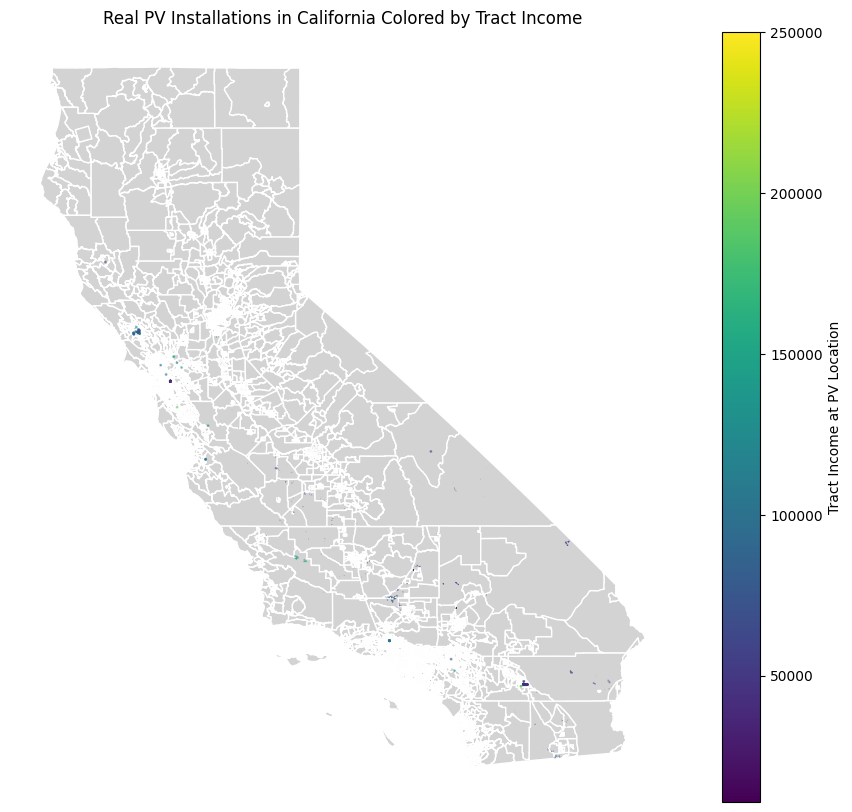

In [9]:
if not joined_gdf.empty:
    # Calculate average income of tracts with PV
    avg_income_pv = joined_gdf['Median_Income'].mean()
    avg_income_ca = ca_gdf['Median_Income'].mean()

    print(f"Average Median Income (PV Locations): ${avg_income_pv:,.2f}")
    print(f"Average Median Income (All CA Tracts): ${avg_income_ca:,.2f}")

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 10))
    ca_gdf.plot(ax=ax, color='lightgrey', edgecolor='white')
    
    # Plot PV points colored by income of the tract they are in
    # We use a smaller marker size as there are many points
    joined_gdf.plot(ax=ax, column='Median_Income', cmap='viridis', markersize=1, alpha=0.5, legend=True, legend_kwds={'label': "Tract Income at PV Location"})
    
    ax.set_title("Real PV Installations in California Colored by Tract Income")
    ax.axis('off')
    plt.show()
else:
    print("No PV installations found within California tracts in this dataset subset.")